In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [24]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")
df.shape

(7500, 16)

In [25]:
df = df.drop(columns=["transaction_id", "user_id"])
print(f"Shape after dropping columns: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Shape after dropping columns: (7500, 14)

Columns: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


Missing values summary:
                 missing_count  missing_pct
addiction_level            819        10.92


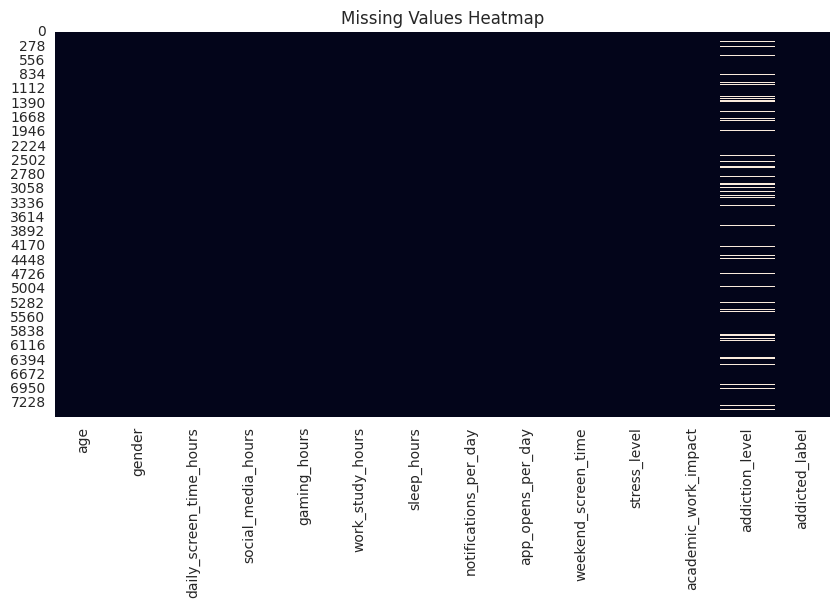


Duplicate rows: 0


In [26]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_with_values = missing_table[missing_table["missing_count"] > 0]
print("Missing values summary:")
print(missing_with_values)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Addicted Label Distribution:
addicted_label
1    0.707733
0    0.292267
Name: proportion, dtype: float64


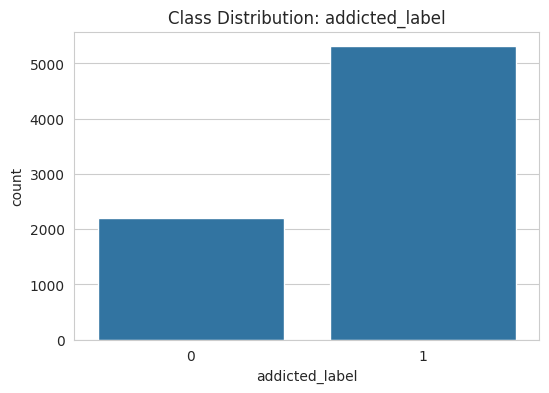


Addiction Level Distribution:
addiction_level
Moderate    2874
Severe      2434
Mild        1373
NaN          819
Name: count, dtype: int64

Missing in addiction_level: 10.92%


In [27]:
target_dist = df["addicted_label"].value_counts(normalize=True)
print("Addicted Label Distribution:")
print(target_dist)

plt.figure(figsize=(6,4))
sns.countplot(x="addicted_label", data=df)
plt.title("Class Distribution: addicted_label")
plt.show()

addiction_level_counts = df["addiction_level"].value_counts(dropna=False)
print("\nAddiction Level Distribution:")
print(addiction_level_counts)
print(f"\nMissing in addiction_level: {df['addiction_level'].isnull().mean() * 100:.2f}%")

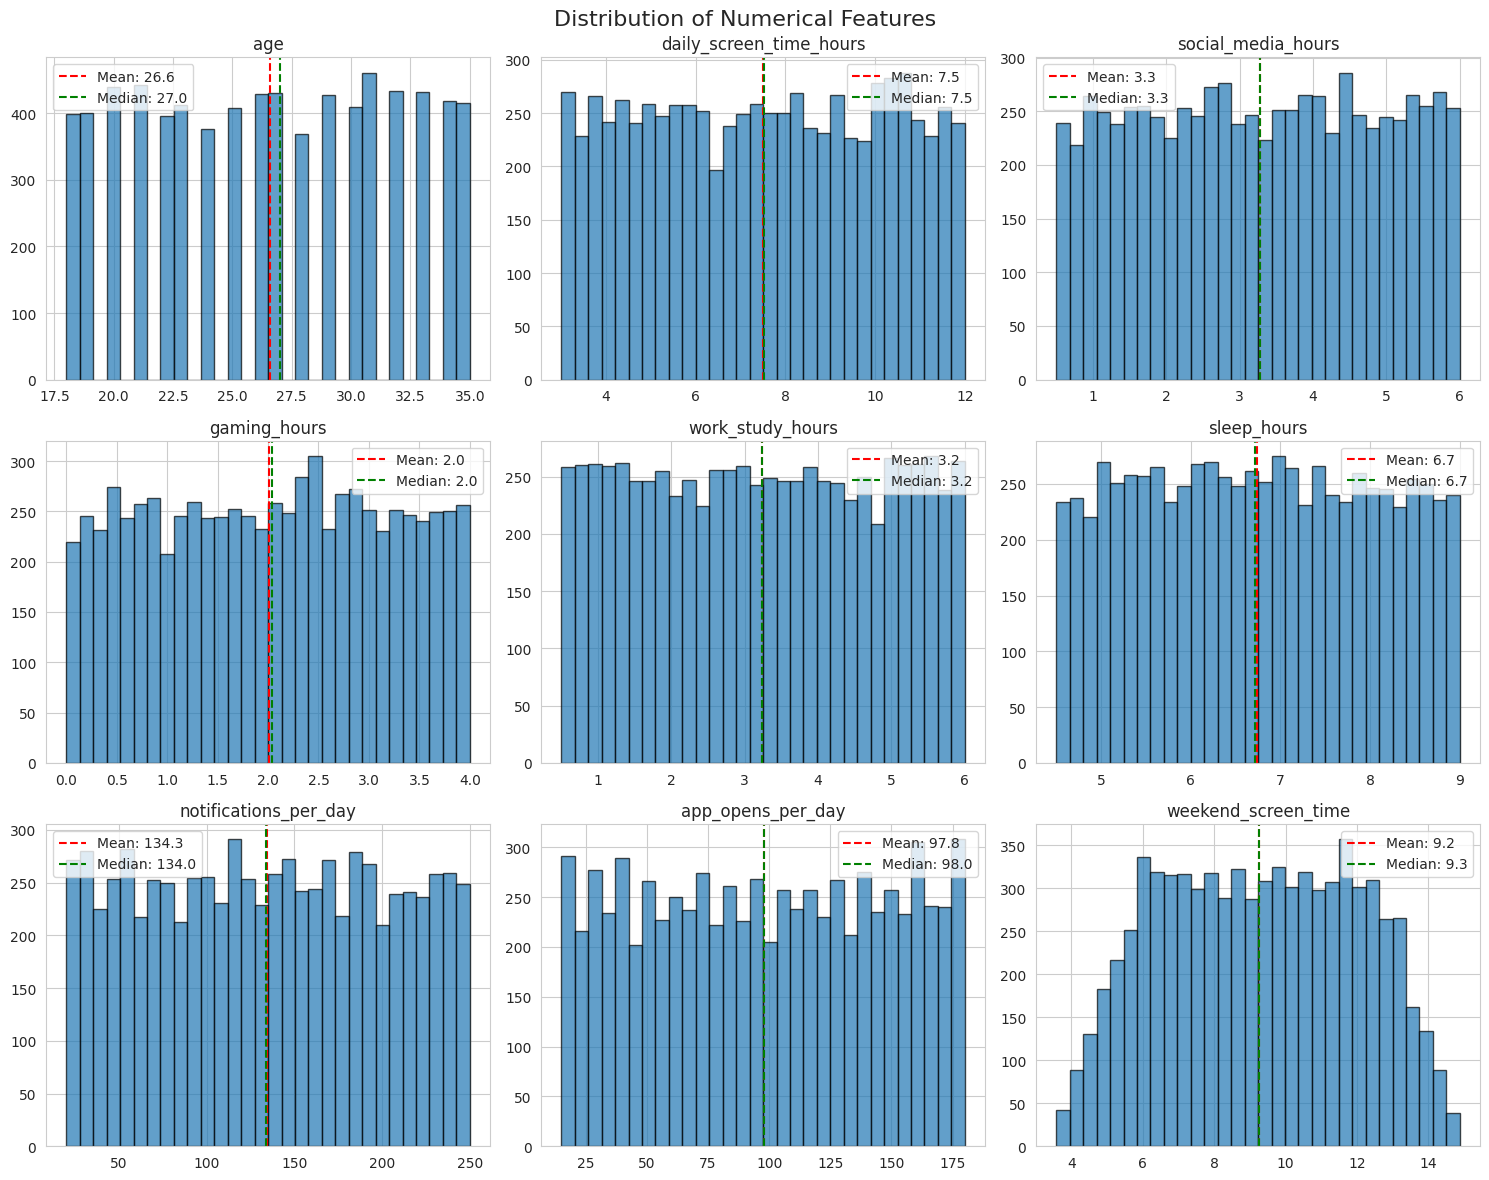

In [28]:
# Cell: Outlier Detection, Distribution Analysis, and Bivariate Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution analysis for numerical features
num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 
            'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 
            'weekend_screen_time']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='dashed', label=f'Mean: {df[col].mean():.1f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='dashed', label=f'Median: {df[col].median():.1f}')
    axes[idx].set_title(f'{col}')
    axes[idx].legend()
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
# Outlier detection using IQR
print("IQR outliers detection)")
print("-"*60)

outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    outlier_summary.append({
        'Feature': col,
        'Outliers Count': len(outliers),
        'Outliers %': f'{outlier_pct:.1f}%',
        'Lower Bound': f'{lower_bound:.2f}',
        'Upper Bound': f'{upper_bound:.2f}'
    })
    print(f"{col}: {len(outliers)} outliers ({outlier_pct:.1f}%)")

IQR outliers detection)
------------------------------------------------------------
age: 0 outliers (0.0%)
daily_screen_time_hours: 0 outliers (0.0%)
social_media_hours: 0 outliers (0.0%)
gaming_hours: 0 outliers (0.0%)
work_study_hours: 0 outliers (0.0%)
sleep_hours: 0 outliers (0.0%)
notifications_per_day: 0 outliers (0.0%)
app_opens_per_day: 0 outliers (0.0%)
weekend_screen_time: 0 outliers (0.0%)


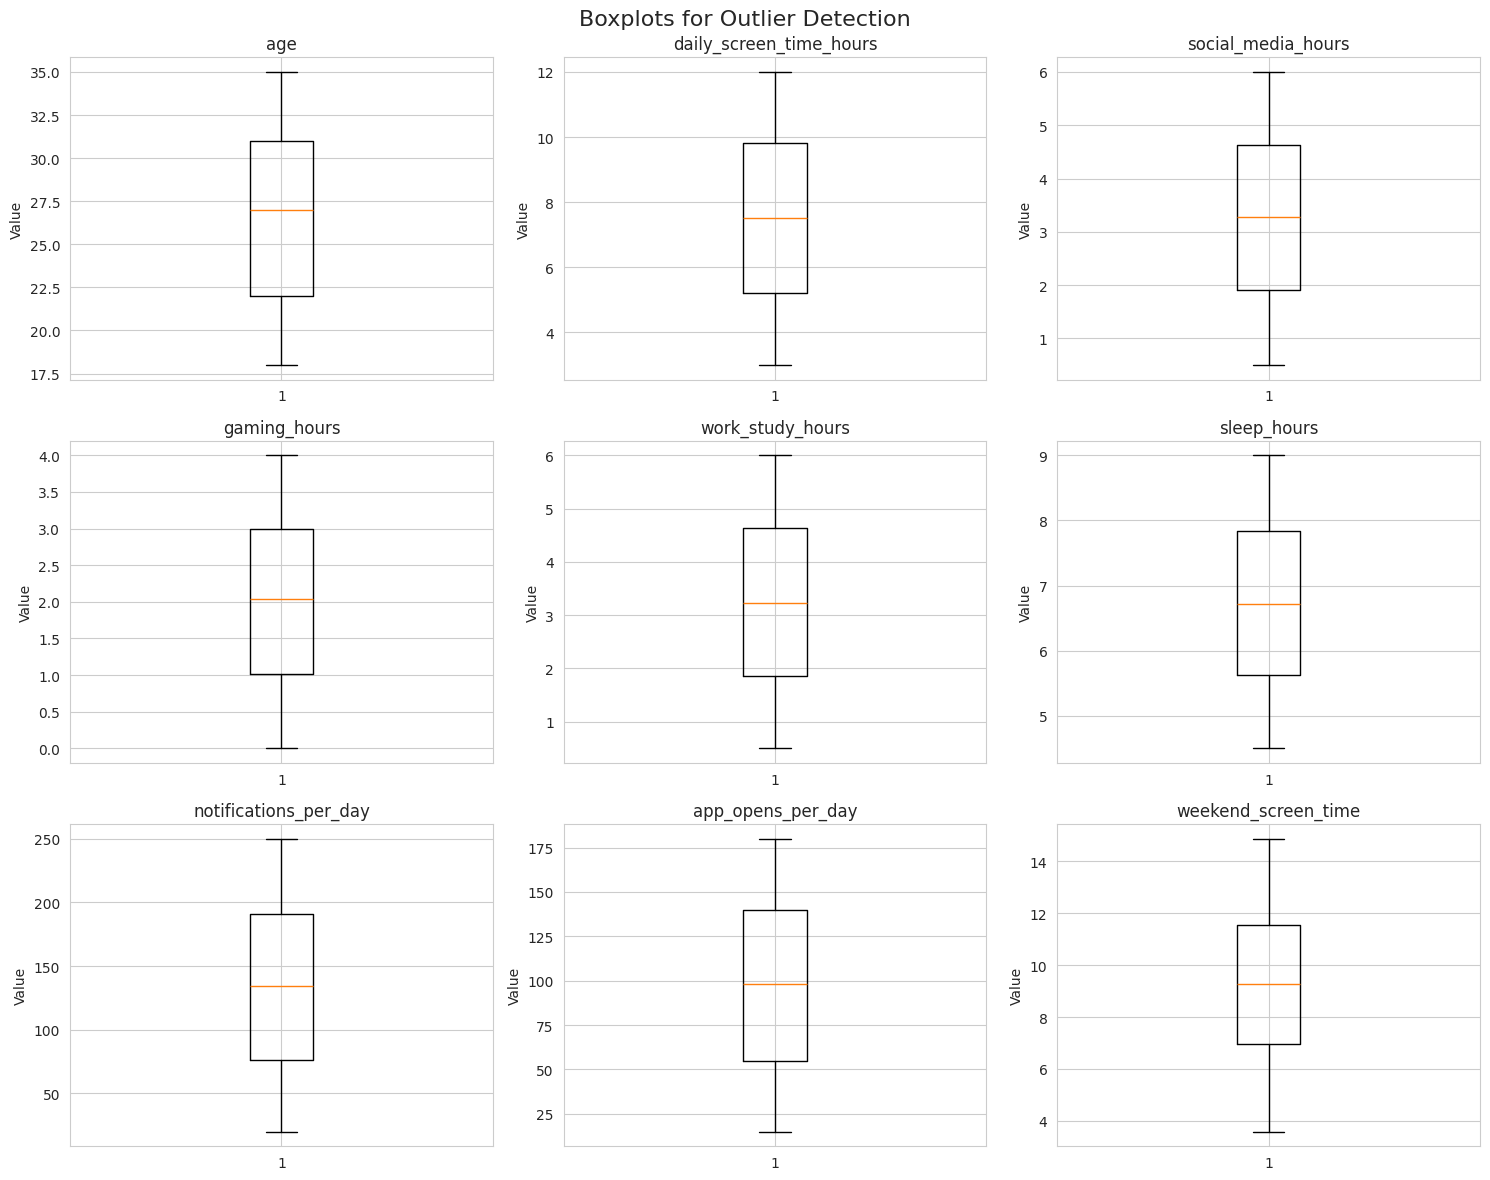

In [30]:
# Boxplots for outlier visualization
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('Value')
plt.suptitle('Boxplots for Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()


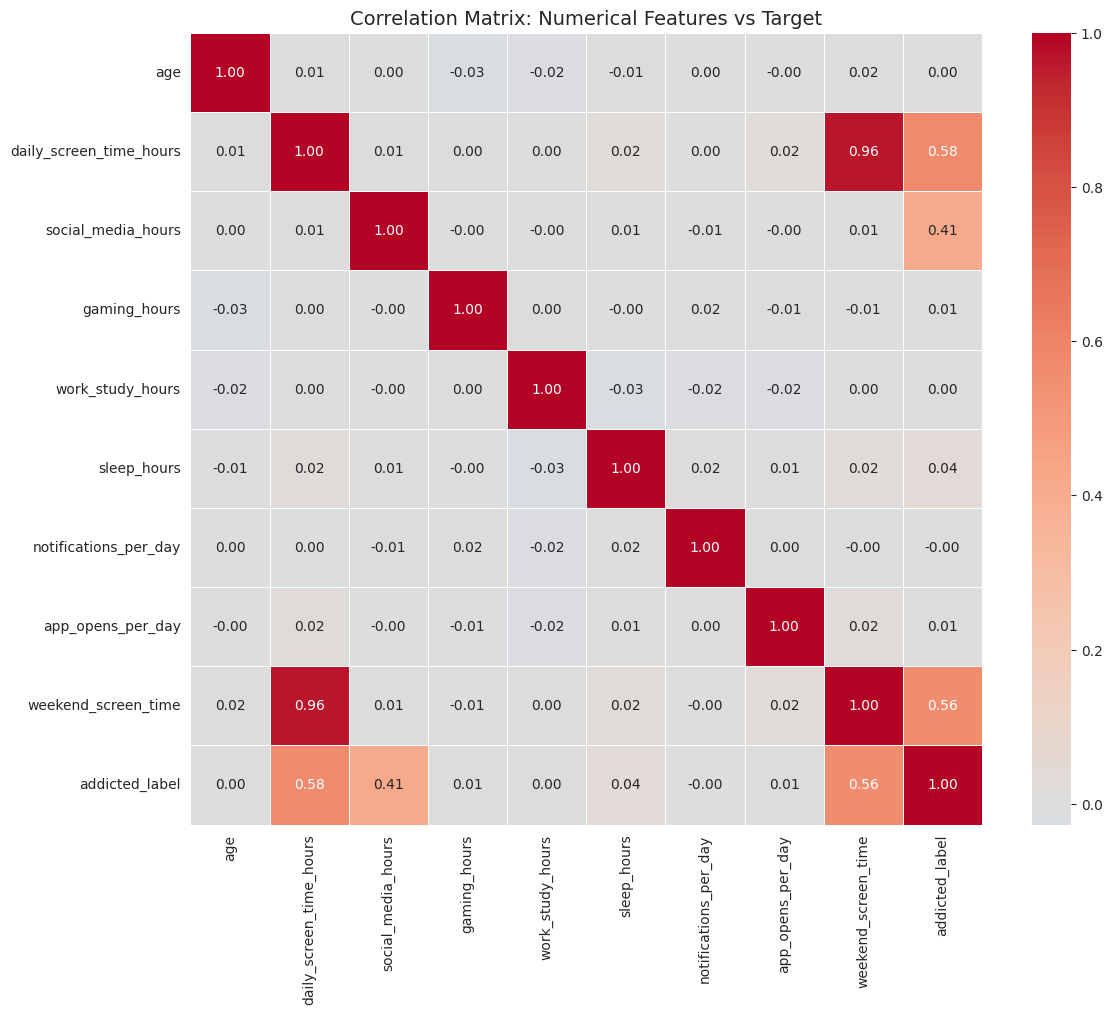

In [31]:
# Bivariate analysis: Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df[num_cols + ['addicted_label']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Numerical Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Top correlations with target
print("Top correlations with addiction label")
print("-"*60)
target_corr = correlation_matrix['addicted_label'].sort_values(ascending=False)
for feature, corr in target_corr.items():
    if feature != 'addicted_label':
        strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
        direction = "positive" if corr > 0 else "negative"
        print(f"{feature:25s}: {corr:7.3f} ({strength} {direction})")


Top correlations with addiction label
------------------------------------------------------------
daily_screen_time_hours  :   0.577 (Strong positive)
weekend_screen_time      :   0.555 (Strong positive)
social_media_hours       :   0.414 (Moderate positive)
sleep_hours              :   0.035 (Weak positive)
app_opens_per_day        :   0.011 (Weak positive)
gaming_hours             :   0.008 (Weak positive)
age                      :   0.004 (Weak positive)
work_study_hours         :   0.001 (Weak positive)
notifications_per_day    :  -0.001 (Weak negative)


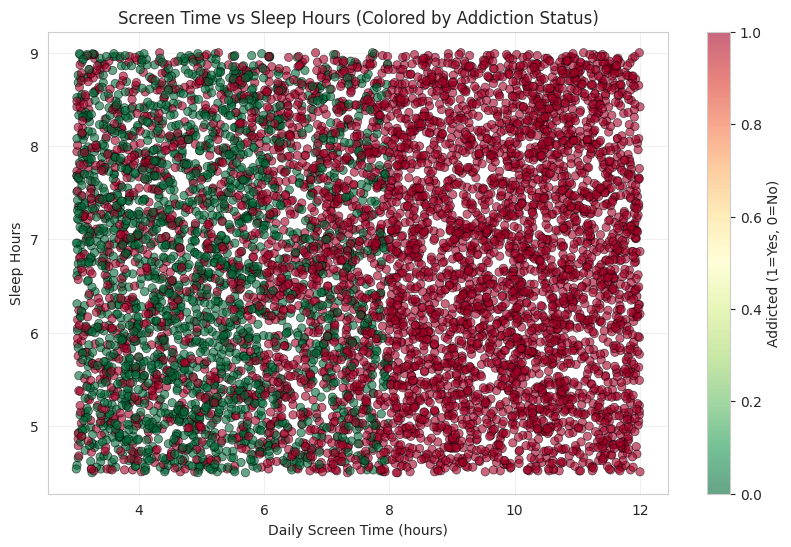

In [33]:
# Screen time vs Sleep by addiction status
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['daily_screen_time_hours'], df['sleep_hours'], 
                      c=df['addicted_label'], cmap='RdYlGn_r', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Addicted (1=Yes, 0=No)')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Sleep Hours')
plt.title('Screen Time vs Sleep Hours (Colored by Addiction Status)')
plt.grid(True, alpha=0.3)
plt.show()


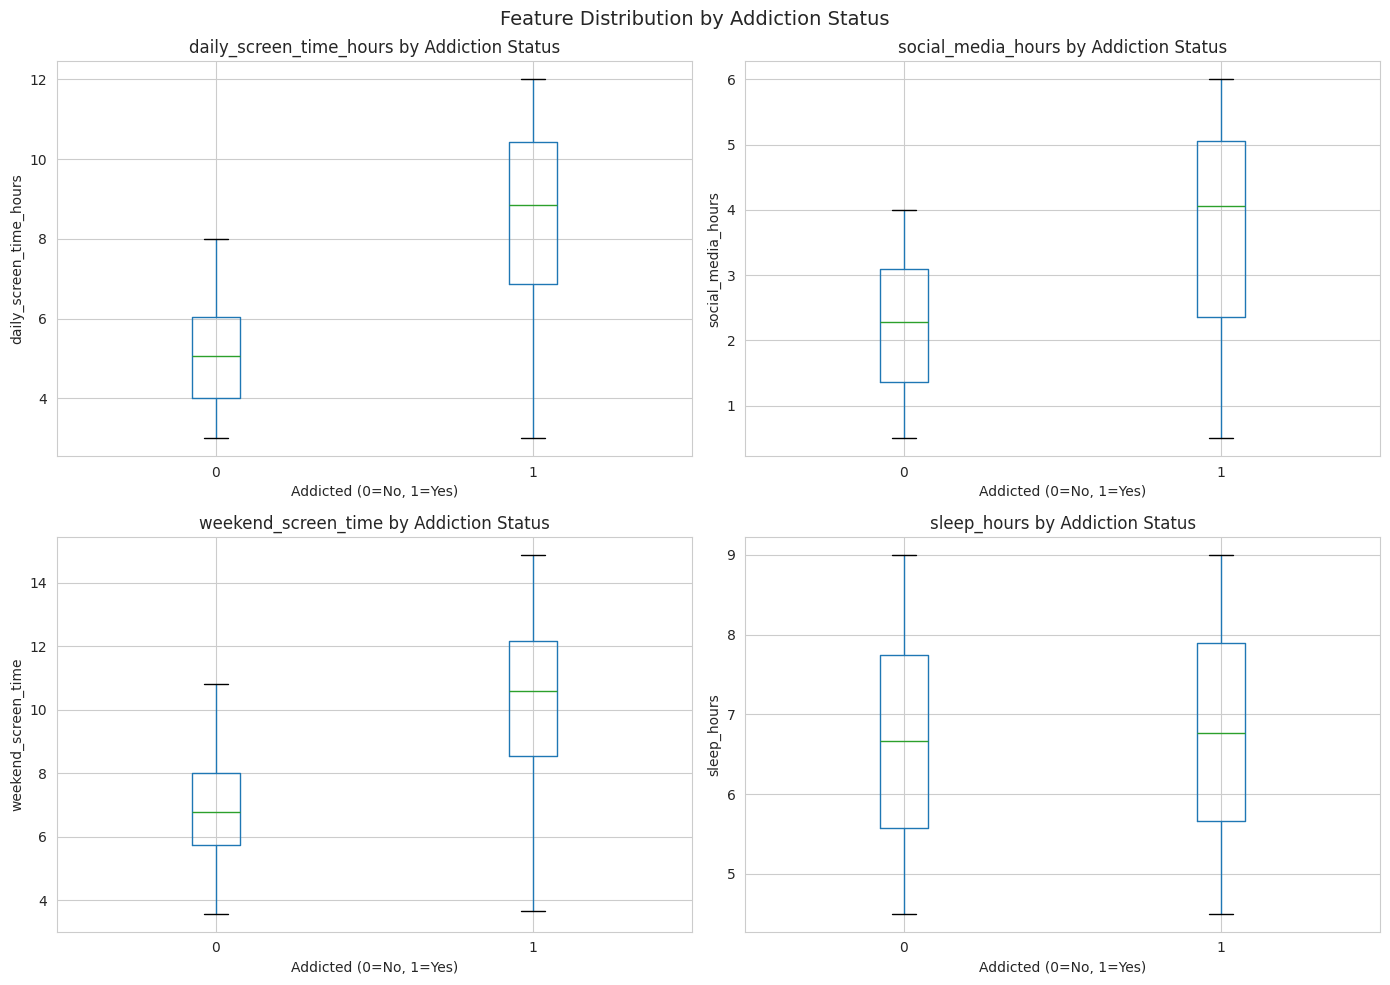

In [34]:
# Bivariate: Feature comparisons across addiction groups
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time', 'sleep_hours']

for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    df.boxplot(column=feature, by='addicted_label', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Addiction Status')
    axes[row, col].set_xlabel('Addicted (0=No, 1=Yes)')
    axes[row, col].set_ylabel(feature)
plt.suptitle('Feature Distribution by Addiction Status', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Statistical summary of differences
print("statistical differences between addicted vs non addicted")
print("-"*60)
for feature in num_cols:
    non_addicted = df[df['addicted_label'] == 0][feature]
    addicted = df[df['addicted_label'] == 1][feature]
    diff_pct = ((addicted.mean() - non_addicted.mean()) / non_addicted.mean()) * 100
    print(f"{feature:25s}: Non-addicted={non_addicted.mean():7.2f} | Addicted={addicted.mean():7.2f} | Diff={diff_pct:+.1f}%")

statistical differences between addicted vs non addicted
------------------------------------------------------------
age                      : Non-addicted=  26.53 | Addicted=  26.58 | Diff=+0.2%
daily_screen_time_hours  : Non-addicted=   5.16 | Addicted=   8.47 | Diff=+64.2%
social_media_hours       : Non-addicted=   2.25 | Addicted=   3.70 | Diff=+64.1%
gaming_hours             : Non-addicted=   2.00 | Addicted=   2.02 | Diff=+1.1%
work_study_hours         : Non-addicted=   3.24 | Addicted=   3.24 | Diff=+0.1%
sleep_hours              : Non-addicted=   6.67 | Addicted=   6.77 | Diff=+1.5%
notifications_per_day    : Non-addicted= 134.33 | Addicted= 134.23 | Diff=-0.1%
app_opens_per_day        : Non-addicted=  97.00 | Addicted=  98.18 | Diff=+1.2%
weekend_screen_time      : Non-addicted=   6.89 | Addicted=  10.21 | Diff=+48.1%


In [36]:
df['sleep_deficit'] = 8 - df['sleep_hours']
new_corr = df[['daily_screen_time_hours', 'sleep_deficit', 'addicted_label']].corr()
print("\nCorrected correlation with sleep_deficit:")
print(f"Screen time vs sleep_deficit: {new_corr.loc['daily_screen_time_hours', 'sleep_deficit']:.3f}")
print(f"Sleep_deficit vs addiction: {new_corr.loc['sleep_deficit', 'addicted_label']:.3f}")


Corrected correlation with sleep_deficit:
Screen time vs sleep_deficit: -0.019
Sleep_deficit vs addiction: -0.035


In [37]:
# Feature Engineering
df_clean = df.copy()
df_clean["total_screen_time"] = df_clean["daily_screen_time_hours"] + df_clean["weekend_screen_time"]
df_clean["digital_intensity"] = df_clean["notifications_per_day"] + df_clean["app_opens_per_day"]
df_clean["social_ratio"] = df_clean["social_media_hours"] / (df_clean["daily_screen_time_hours"] + 1e-6)
df_clean["sleep_deficit"] = 8 - df_clean["sleep_hours"]
df_clean["entertainment_load"] = df_clean["social_media_hours"] + df_clean["gaming_hours"]
df_clean["stress_level"] = df_clean["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
df_clean = pd.get_dummies(df_clean, columns=["gender"], drop_first=True)
df_clean["academic_work_impact"] = df_clean["academic_work_impact"].map({"No": 0, "Yes": 1})
df_clean = df_clean.drop(columns=["addiction_level"])

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"\nNew features created: total_screen_time, digital_intensity, social_ratio, sleep_deficit, entertainment_load")

Cleaned dataset shape: (7500, 19)

New features created: total_screen_time, digital_intensity, social_ratio, sleep_deficit, entertainment_load


In [38]:
X = df_clean.drop(columns=["addicted_label"])
y = df_clean["addicted_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: (6000, 18)
Test set: (1500, 18)

Training target distribution:
addicted_label
1    0.707667
0    0.292333
Name: proportion, dtype: float64


In [39]:
X = df_clean.drop(columns=["addicted_label"])
y = df_clean["addicted_label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: (6000, 18)
Test set: (1500, 18)

Training target distribution:
addicted_label
1    0.707667
0    0.292333
Name: proportion, dtype: float64


In [40]:
# Method 1 - Scaling Models (Logistic Regression, SVM, KNN)
models_scaled = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced"),
    "KNN": KNeighborsClassifier()
}

results_method1 = {}
for name, model in models_scaled.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results_method1[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{name}")
    print(f"Accuracy: {results_method1[name]['Accuracy']:.4f}")
    print(f"F1: {results_method1[name]['F1']:.4f}")
    print(f"ROC-AUC: {results_method1[name]['ROC-AUC']:.4f}")


Logistic Regression
Accuracy: 0.9100
F1: 0.9343
ROC-AUC: 0.9747

SVM (RBF)
Accuracy: 0.9260
F1: 0.9459
ROC-AUC: 0.9779

KNN
Accuracy: 0.8933
F1: 0.9263
ROC-AUC: 0.9449


In [41]:
# Method 2 - Tree Models (Random Forest, Gradient Boosting)
models_tree = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results_method2 = {}
for name, model in models_tree.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results_method2[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{name}")
    print(f"Accuracy: {results_method2[name]['Accuracy']:.4f}")
    print(f"F1: {results_method2[name]['F1']:.4f}")
    print(f"ROC-AUC: {results_method2[name]['ROC-AUC']:.4f}")


Random Forest
Accuracy: 0.9287
F1: 0.9495
ROC-AUC: 0.9887

Gradient Boosting
Accuracy: 0.9393
F1: 0.9569
ROC-AUC: 0.9898


In [42]:
# Compare Results and Select Best Model
print("=== METHOD 1 (Scaling Models) ===")
print(pd.DataFrame(results_method1).T.sort_values("F1", ascending=False))

print("\n=== METHOD 2 (Tree Models) ===")
print(pd.DataFrame(results_method2).T.sort_values("F1", ascending=False))

best_model_name = max(results_method2, key=lambda x: results_method2[x]['F1'])
print(f"\nBest model: {best_model_name}")
print(f"F1 Score: {results_method2[best_model_name]['F1']:.4f}")
print(f"ROC-AUC: {results_method2[best_model_name]['ROC-AUC']:.4f}")

=== METHOD 1 (Scaling Models) ===
                     Accuracy        F1   ROC-AUC
SVM (RBF)            0.926000  0.945880  0.977919
Logistic Regression  0.910000  0.934307  0.974652
KNN                  0.893333  0.926267  0.944925

=== METHOD 2 (Tree Models) ===
                   Accuracy        F1   ROC-AUC
Gradient Boosting  0.939333  0.956852  0.989816
Random Forest      0.928667  0.949504  0.988705

Best model: Gradient Boosting
F1 Score: 0.9569
ROC-AUC: 0.9898


Final Model Performance (Full Features):
Accuracy: 0.9393
F1 Score: 0.9569
ROC-AUC: 0.9898

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       438
           1       0.96      0.95      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.93      0.93      1500
weighted avg       0.94      0.94      0.94      1500


Top 10 Most Important Features:
sleep_deficit              0.000753
age                        0.000754
digital_intensity          0.001063
work_study_hours           0.001559
total_screen_time          0.002115
entertainment_load         0.002467
social_ratio               0.003463
weekend_screen_time        0.004365
social_media_hours         0.488900
daily_screen_time_hours    0.491983
dtype: float64


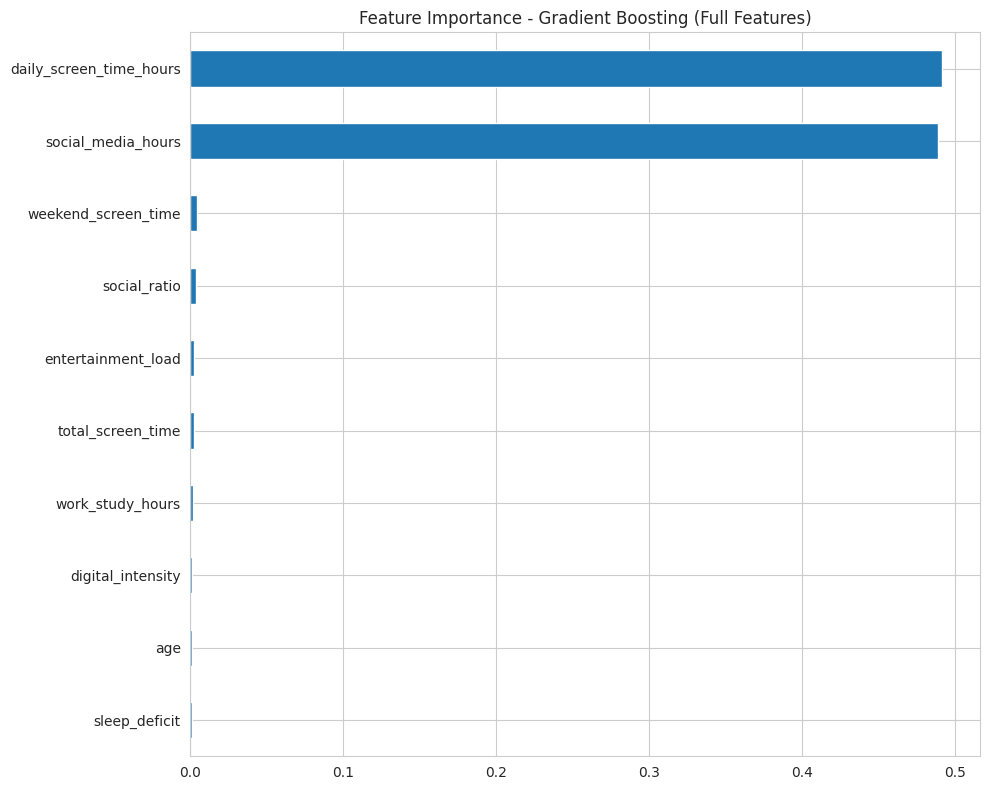

In [43]:
# Train Final Model 
final_model_full = GradientBoostingClassifier(random_state=42)
final_model_full.fit(X_train, y_train)

y_pred_full = final_model_full.predict(X_test)
y_proba_full = final_model_full.predict_proba(X_test)[:, 1]

print("Final Model Performance (Full Features):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_full):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_full):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_full):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_full))

# Feature importance
importance_full = pd.Series(final_model_full.feature_importances_, index=X.columns).sort_values()
print("\nTop 10 Most Important Features:")
print(importance_full.tail(10))

plt.figure(figsize=(10, 8))
importance_full.tail(10).plot(kind="barh")
plt.title("Feature Importance - Gradient Boosting (Full Features)")
plt.tight_layout()
plt.show()

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

In [45]:
# Simplified Model (2 Features)
X_simple = df_clean[['daily_screen_time_hours', 'social_media_hours']]
y = df_clean['addicted_label']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, stratify=y, random_state=42
)

simple_model = GradientBoostingClassifier(random_state=42)
simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)
y_proba_s = simple_model.predict_proba(X_test_s)[:, 1]

print("SIMPLIFIED MODEL PERFORMANCE (2 Features)")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test_s, y_pred_s):.4f}")
print(f"F1 Score: {f1_score(y_test_s, y_pred_s):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_s, y_proba_s):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s, target_names=['Not Addicted', 'Addicted']))

# Confusion Matrix
cm = confusion_matrix(y_test_s, y_pred_s)
print("\nConfusion Matrix:")
print(f"            Predicted")
print(f"            No    Yes")
print(f"Actual No   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       Yes  {cm[1,0]:4d}  {cm[1,1]:4d}")

SIMPLIFIED MODEL PERFORMANCE (2 Features)
Accuracy: 0.9327
F1 Score: 0.9523
ROC-AUC: 0.9888

Classification Report:
              precision    recall  f1-score   support

Not Addicted       0.88      0.89      0.89       438
    Addicted       0.96      0.95      0.95      1062

    accuracy                           0.93      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500


Confusion Matrix:
            Predicted
            No    Yes
Actual No    391    47
       Yes    54  1008


In [46]:
# Compare Full vs Simplified Model
print("="*50)
print("COMPARISON: Full Model vs Simplified (2 Features)")
print("="*50)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'ROC-AUC'],
    'Full Model': [
        accuracy_score(y_test, y_pred_full),
        f1_score(y_test, y_pred_full),
        roc_auc_score(y_test, y_proba_full)
    ],
    'Simplified': [
        accuracy_score(y_test_s, y_pred_s),
        f1_score(y_test_s, y_pred_s),
        roc_auc_score(y_test_s, y_proba_s)
    ]
})

comparison_df['Difference'] = comparison_df['Full Model'] - comparison_df['Simplified']
print(comparison_df.round(4).to_string(index=False))

COMPARISON: Full Model vs Simplified (2 Features)
  Metric  Full Model  Simplified  Difference
Accuracy      0.9393      0.9327      0.0067
F1 Score      0.9569      0.9523      0.0046
 ROC-AUC      0.9898      0.9888      0.0010

✓ Simplified model performs nearly identically
→ RECOMMENDED: Deploy simplified model with 2 features


Threshold optimization
Threshold 0.3: Accuracy=0.9260, F1=0.9502
Threshold 0.4: Accuracy=0.9240, F1=0.9479
Threshold 0.5: Accuracy=0.9327, F1=0.9523
Threshold 0.6: Accuracy=0.9407, F1=0.9564
Threshold 0.7: Accuracy=0.9407, F1=0.9563


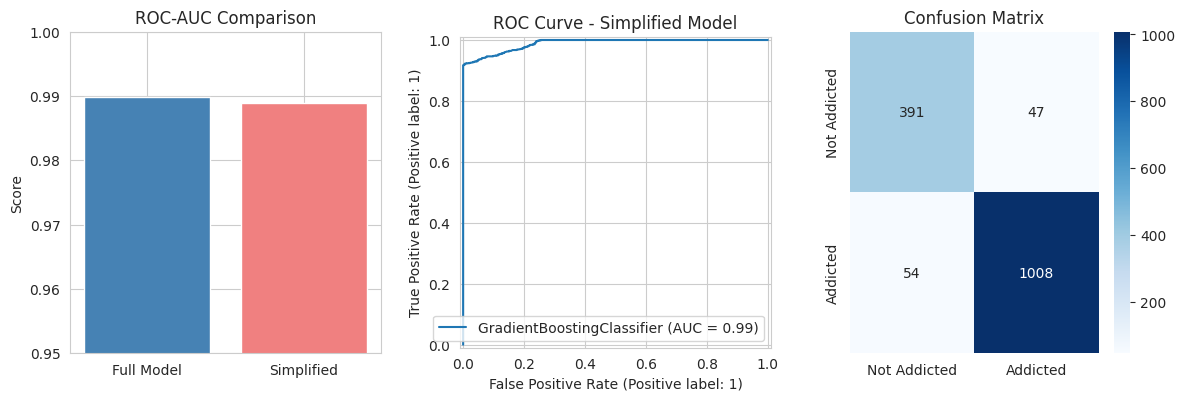

In [47]:
print("Threshold optimization")

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in thresholds:
    y_pred_thresh = (y_proba_s >= thresh).astype(int)
    acc = accuracy_score(y_test_s, y_pred_thresh)
    f1 = f1_score(y_test_s, y_pred_thresh)
    print(f"Threshold {thresh:.1f}: Accuracy={acc:.4f}, F1={f1:.4f}")

# Visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.bar(['Full Model', 'Simplified'], 
        [roc_auc_score(y_test, y_proba_full), roc_auc_score(y_test_s, y_proba_s)],
        color=['steelblue', 'lightcoral'])
plt.title('ROC-AUC Comparison')
plt.ylabel('Score')
plt.ylim(0.95, 1.0)

plt.subplot(1, 3, 2)
RocCurveDisplay.from_estimator(simple_model, X_test_s, y_test_s, ax=plt.gca())
plt.title('ROC Curve - Simplified Model')

plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Addicted', 'Addicted'],
            yticklabels=['Not Addicted', 'Addicted'])
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [48]:
# Cross-Validation for All Models (Scaling Models)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

cv_results = []

for name, model in models_cv.items():
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    cv_auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    cv_results.append({
        "Model": name,
        "CV_Acc_Mean": round(cv_acc.mean(), 4),
        "CV_Acc_Std": round(cv_acc.std(), 4),
        "CV_F1_Mean": round(cv_f1.mean(), 4),
        "CV_F1_Std": round(cv_f1.std(), 4),
        "CV_AUC_Mean": round(cv_auc.mean(), 4),
        "CV_AUC_Std": round(cv_auc.std(), 4),
        "Test_Acc": round(accuracy_score(y_test, y_pred), 4),
        "Test_F1": round(f1_score(y_test, y_pred), 4),
        "Test_AUC": round(roc_auc_score(y_test, y_proba), 4)
    })

results_cv_df = pd.DataFrame(cv_results)
print(results_cv_df.to_string(index=False))

best_model_row = results_cv_df.loc[results_cv_df['CV_AUC_Mean'].idxmax()]
print(f"\n{'-'*60}")
print(f"best model with cv: {best_model_row['Model']}")
print(f"CV AUC: {best_model_row['CV_AUC_Mean']} (±{best_model_row['CV_AUC_Std']})")
print(f"Test AUC: {best_model_row['Test_AUC']}")
print(f"{'-'*60}")

              Model  CV_Acc_Mean  CV_Acc_Std  CV_F1_Mean  CV_F1_Std  CV_AUC_Mean  CV_AUC_Std  Test_Acc  Test_F1  Test_AUC
Logistic Regression       0.9103      0.0083      0.9348     0.0064       0.9742      0.0042    0.9100   0.9343    0.9747
          SVM (RBF)       0.9118      0.0095      0.9356     0.0073       0.9757      0.0032    0.9260   0.9459    0.9779
                KNN       0.8908      0.0043      0.9239     0.0032       0.9396      0.0053    0.8933   0.9263    0.9449
      Random Forest       0.9338      0.0085      0.9532     0.0061       0.9890      0.0022    0.9287   0.9495    0.9886
  Gradient Boosting       0.9332      0.0051      0.9524     0.0037       0.9882      0.0021    0.9393   0.9569    0.9898

------------------------------------------------------------
best model with cv: Random Forest
CV AUC: 0.989 (±0.0022)
Test AUC: 0.9886
------------------------------------------------------------


In [52]:
# CELL: Cross-Validation for SIMPLIFIED Models (2 Features Only)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Prepare 2-feature dataset
X_simple = df_clean[['daily_screen_time_hours', 'social_media_hours']]
y = df_clean['addicted_label']

# Split data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, stratify=y, random_state=42
)

# Define simplified models
simplified_models = {
    "Logistic Regression (2F)": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF) (2F)": SVC(probability=True, class_weight="balanced"),
    "KNN (2F)": KNeighborsClassifier(),
    "Random Forest (2F)": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Gradient Boosting (2F)": GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
simplified_cv_results = []

for name, model in simplified_models.items():
    # Cross-validation on training set
    cv_acc = cross_val_score(model, X_train_s, y_train_s, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(model, X_train_s, y_train_s, cv=cv, scoring='f1')
    cv_auc = cross_val_score(model, X_train_s, y_train_s, cv=cv, scoring='roc_auc')
    
    # Train and evaluate on test set
    model.fit(X_train_s, y_train_s)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    
    simplified_cv_results.append({
        "Model": name,
        "CV_Acc_Mean": round(cv_acc.mean(), 4),
        "CV_Acc_Std": round(cv_acc.std(), 4),
        "CV_F1_Mean": round(cv_f1.mean(), 4),
        "CV_F1_Std": round(cv_f1.std(), 4),
        "CV_AUC_Mean": round(cv_auc.mean(), 4),
        "CV_AUC_Std": round(cv_auc.std(), 4),
        "Test_Acc": round(accuracy_score(y_test_s, y_pred), 4),
        "Test_F1": round(f1_score(y_test_s, y_pred), 4),
        "Test_AUC": round(roc_auc_score(y_test_s, y_proba), 4)
    })

# Display results
simplified_results_df = pd.DataFrame(simplified_cv_results)
print("="*70)
print("CROSS-VALIDATION RESULTS - SIMPLIFIED MODELS (2 FEATURES)")
print("="*70)
print(simplified_results_df.to_string(index=False))

# Find best simplified model
best_simple = simplified_results_df.loc[simplified_results_df['CV_AUC_Mean'].idxmax()]
print(f"\n{'='*70}")
print(f"BEST SIMPLIFIED MODEL: {best_simple['Model']}")
print(f"CV AUC: {best_simple['CV_AUC_Mean']} (±{best_simple['CV_AUC_Std']})")
print(f"Test AUC: {best_simple['Test_AUC']}")
print(f"{'='*70}")

CROSS-VALIDATION RESULTS - SIMPLIFIED MODELS (2 FEATURES)
                   Model  CV_Acc_Mean  CV_Acc_Std  CV_F1_Mean  CV_F1_Std  CV_AUC_Mean  CV_AUC_Std  Test_Acc  Test_F1  Test_AUC
Logistic Regression (2F)       0.8655      0.0099      0.9005     0.0077       0.9528      0.0062    0.8767   0.9094    0.9543
          SVM (RBF) (2F)       0.9242      0.0094      0.9442     0.0073       0.9795      0.0033    0.9233   0.9434    0.9799
                KNN (2F)       0.9302      0.0086      0.9506     0.0064       0.9834      0.0031    0.9267   0.9482    0.9808
      Random Forest (2F)       0.9335      0.0030      0.9529     0.0023       0.9891      0.0011    0.9273   0.9486    0.9884
  Gradient Boosting (2F)       0.9363      0.0053      0.9546     0.0038       0.9896      0.0014    0.9327   0.9523    0.9888

BEST SIMPLIFIED MODEL: Gradient Boosting (2F)
CV AUC: 0.9896 (±0.0014)
Test AUC: 0.9888
